In [1]:
# Cell ID: 0MMwOI6gRx9t
!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si
import warnings

# Suppress minor pandas formatting warnings in Colab
warnings.filterwarnings('ignore')

<!-- Cell ID: 436e49ea -->
This cell installs the `yfinance` library, which is used to fetch financial data, including options chains, from Yahoo Finance. It then imports all the necessary libraries for the project:
- `yfinance` for financial data.
- `pandas` for data manipulation (DataFrames).
- `numpy` for numerical operations.
- `matplotlib.pyplot` for data visualization.
- `scipy.stats` for statistical functions, specifically for the Black-Scholes Gamma calculation.
- `warnings` to suppress any potential warning messages during execution.

In [2]:
# Cell ID: _2QC8ymXSeMJ
# ==========================================
# 1. UTILITY FUNCTIONS & MATH ENGINE
# ==========================================
def format_gex_label(val):
    """Transforms raw numerical GEX values into clean shorthand strings (e.g., 31.4M)"""
    if pd.isna(val) or val == 0:
        return ""
    if abs(val) >= 1_000_000:
        return f"{val / 1_000_000:.1f}M"
    elif abs(val) >= 1_000:
        return f"{val / 1_000:.1f}K"
    return f"{val:.0f}"

def calc_gamma(S, K, T, r, sigma):
    """Calculates theoretical Black-Scholes option gamma"""
    if T <= 0 or sigma <= 0: return 0.001
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return si.norm.pdf(d1) / (S * sigma * np.sqrt(T))

<!-- Cell ID: 5ac1ee48 -->
This section defines two utility functions:
- `format_gex_label`: This helper function converts raw numerical GEX values into a more readable shorthand string format (e.g., '31.4M' for millions, '1.2K' for thousands). It also handles zero or NaN values by returning an empty string.
- `calc_gamma`: This function calculates the Black-Scholes Gamma for an option. It takes the underlying spot price (`S`), strike price (`K`), time to expiration (`T`), risk-free rate (`r`), and implied volatility (`sigma`) as inputs. It returns a small default value if `T` or `sigma` are non-positive to prevent mathematical errors.

In [3]:
import datetime

# ==========================================
# 2. DATA PIPELINE: FETCH & FILTER
# ==========================================
print("Extracting live options data from Yahoo Finance...")
ticker_symbol = "SPY"
ticker = yf.Ticker(ticker_symbol)

# Force 1-minute intervals to capture the literal last after-hours tick, covering a few days to ensure we get the latest
history_data = ticker.history(period="5d", interval="1m", prepost=True).dropna(subset=['Close'])
spot_price = history_data['Close'].iloc[-1]
last_trade_datetime_est = history_data.index[-1].tz_convert('America/New_York') # Define last_trade_datetime_est

# Select multiple upcoming expiration dates
num_expiries = 5 # Display the next 5 available expiries
expiry_dates = ticker.options[:num_expiries] # Get the first 'num_expiries' available dates

options_data_by_expiry = {}
for exp_date_str in expiry_dates:
    opt_chain = ticker.option_chain(exp_date_str)
    options_data_by_expiry[exp_date_str] = (opt_chain.calls, opt_chain.puts)

# Consolidate strikes from all expiries and filter to a tight 35-strike radius around the spot price
all_strikes_combined = []
for exp_date_str in expiry_dates:
    calls_df, puts_df = options_data_by_expiry[exp_date_str]
    all_strikes_combined.extend(calls_df['strike'].tolist() + puts_df['strike'].tolist())
all_strikes = sorted(list(set(all_strikes_combined)))

# Get the 35 strikes closest to spot, then sort them numerically.
# Then, select the central 29 strikes to reduce the y-axis scale by 6.
temp_closest_strikes = sorted(all_strikes, key=lambda x: abs(x - spot_price))[:35]
temp_closest_strikes.sort()

num_strikes_to_display = 29 # 35 - 6
start_idx = (len(temp_closest_strikes) - num_strikes_to_display) // 2
end_idx = start_idx + num_strikes_to_display
closest_strikes = temp_closest_strikes[start_idx:end_idx]

# Redefine heatmap columns to be expiration dates
heatmap_data = np.zeros((len(closest_strikes), len(expiry_dates)))

r = 0.045     # Assumed risk-free rate
# T (time to expiration) will now be calculated dynamically for each expiry date in the next cell

Extracting live options data from Yahoo Finance...


In [4]:
# Cell ID: 74882903
from datetime import datetime

# ==========================================
# 3. POPULATE THE GEX MATRIX
# ==========================================
current_date = datetime.today().date() # Corrected: Access today() method of the datetime class and then its date attribute

for t_idx, exp_date_str in enumerate(expiry_dates): # Loop through expiration dates
    calls_for_expiry, puts_for_expiry = options_data_by_expiry[exp_date_str]

    # Calculate time to expiration (T) for the current expiry
    exp_date = datetime.strptime(exp_date_str, '%Y-%m-%d').date()
    T = (exp_date - current_date).days / 365.0
    if T <= 0: T = 1 / 365.0 # Ensure T is at least 1 day for calculation if already expired or 0DTE

    current_spot_for_gamma = spot_price # Spot price is constant for all expiries in this run

    for s_idx, strike in enumerate(closest_strikes):
        c_row = calls_for_expiry[calls_for_expiry['strike'] == strike]
        p_row = puts_for_expiry[puts_for_expiry['strike'] == strike]

        # Extract Open Interest securely
        c_oi = c_row['openInterest'].values[0] if not c_row.empty and pd.notna(c_row['openInterest'].values[0]) else 0
        p_oi = p_row['openInterest'].values[0] if not p_row.empty and pd.notna(p_row['openInterest'].values[0]) else 0

        # Extract Implied Volatility
        c_iv = c_row['impliedVolatility'].values[0] if not c_row.empty else 0.15
        p_iv = p_row['impliedVolatility'].values[0] if not p_row.empty else 0.15

        # Professional dollar-weighted formula
        # 1. We scale by (Spot Price**2) to convert contract count into dollar-hedging sensitivity
        # 2. We multiply by 0.01 to measure exposure to a 1% index move
        spot_price_squared = spot_price ** 2
        gamma = calc_gamma(spot_price, strike, T, r, (c_iv + p_iv) / 2)

        # This formula calculates 'Dollars per 1% change in SPY'
        net_gex = ((c_oi * gamma * 100) - (p_oi * gamma * 100)) * spot_price_squared * 0.01

        heatmap_data[s_idx, t_idx] = np.nan_to_num(net_gex, nan=0.0)

In [5]:
import pandas as pd
import numpy as np

# ==========================================
# 4. PREPARE THE VISUAL ARRAYS
# ==========================================
# Organize DataFrames (Descending strikes on the Y-Axis)
df_heatmap = pd.DataFrame(heatmap_data, index=closest_strikes, columns=expiry_dates).sort_index(ascending=False)

# Format the labels using pandas map/applymap depending on version compatibility
try:
    df_annotations = df_heatmap.map(format_gex_label) # Pandas 2.1+
except AttributeError:
    df_annotations = df_heatmap.applymap(format_gex_label) # Older Pandas

# Locate the absolute maximum value across the entire matrix (The Outlier Block)
absolute_matrix = np.abs(df_heatmap.values)
global_max_val = np.max(absolute_matrix)

# Identify the strike with the maximum absolute GEX for the current day (first column)
current_day_gex_for_abs_max_cell = df_heatmap.iloc[:, 0]
abs_max_gex_row_idx_for_cell_color = -1 # Initialize with an invalid index

if not current_day_gex_for_abs_max_cell.empty:
    abs_max_gex_strike_for_cell_color = current_day_gex_for_abs_max_cell.abs().idxmax()
    abs_max_gex_row_idx_for_cell_color = df_heatmap.index.get_loc(abs_max_gex_strike_for_cell_color)

# Map raw variables directly to fixed custom RGBA pixel bounds
rgba_matrix = np.zeros((df_heatmap.shape[0], df_heatmap.shape[1], 4))

for r_idx in range(df_heatmap.shape[0]):
    for c_idx in range(df_heatmap.shape[1]):
        val = df_heatmap.iloc[r_idx, c_idx]

        # NEW RULE: Highest Absolute GEX for the current day (first column) -> Paint cell White
        if abs_max_gex_row_idx_for_cell_color != -1 and r_idx == abs_max_gex_row_idx_for_cell_color and c_idx == 0:
            rgba_matrix[r_idx, c_idx] = [1.0, 1.0, 1.0, 1.0] # White

        # RULE 1: Global Maximum Exposure -> Paint cell Bright Blue
        elif np.abs(val) == global_max_val and global_max_val > 0:
            rgba_matrix[r_idx, c_idx] = [0.0, 0.68, 1.0, 1.0]

        # RULE 2: Positive Net GEX -> Scale green intensity
        elif val > 0:
            intensity = min(val / (global_max_val * 0.6), 1.0)
            rgba_matrix[r_idx, c_idx] = [0.0, 0.45 * intensity + 0.1, 0.05, 1.0]

        # RULE 3: Negative Net GEX -> Scale red intensity
        elif val < 0:
            intensity = min(np.abs(val) / (global_max_val * 0.6), 1.0)
            rgba_matrix[r_idx, c_idx] = [0.45 * intensity + 0.0, 0.0, 0.05, 1.0]

        # RULE 4: Neutral/Blank Zones -> Muted Dark Background Slate
        else:
            rgba_matrix[r_idx, c_idx] = [0.11, 0.13, 0.18, 1.0]


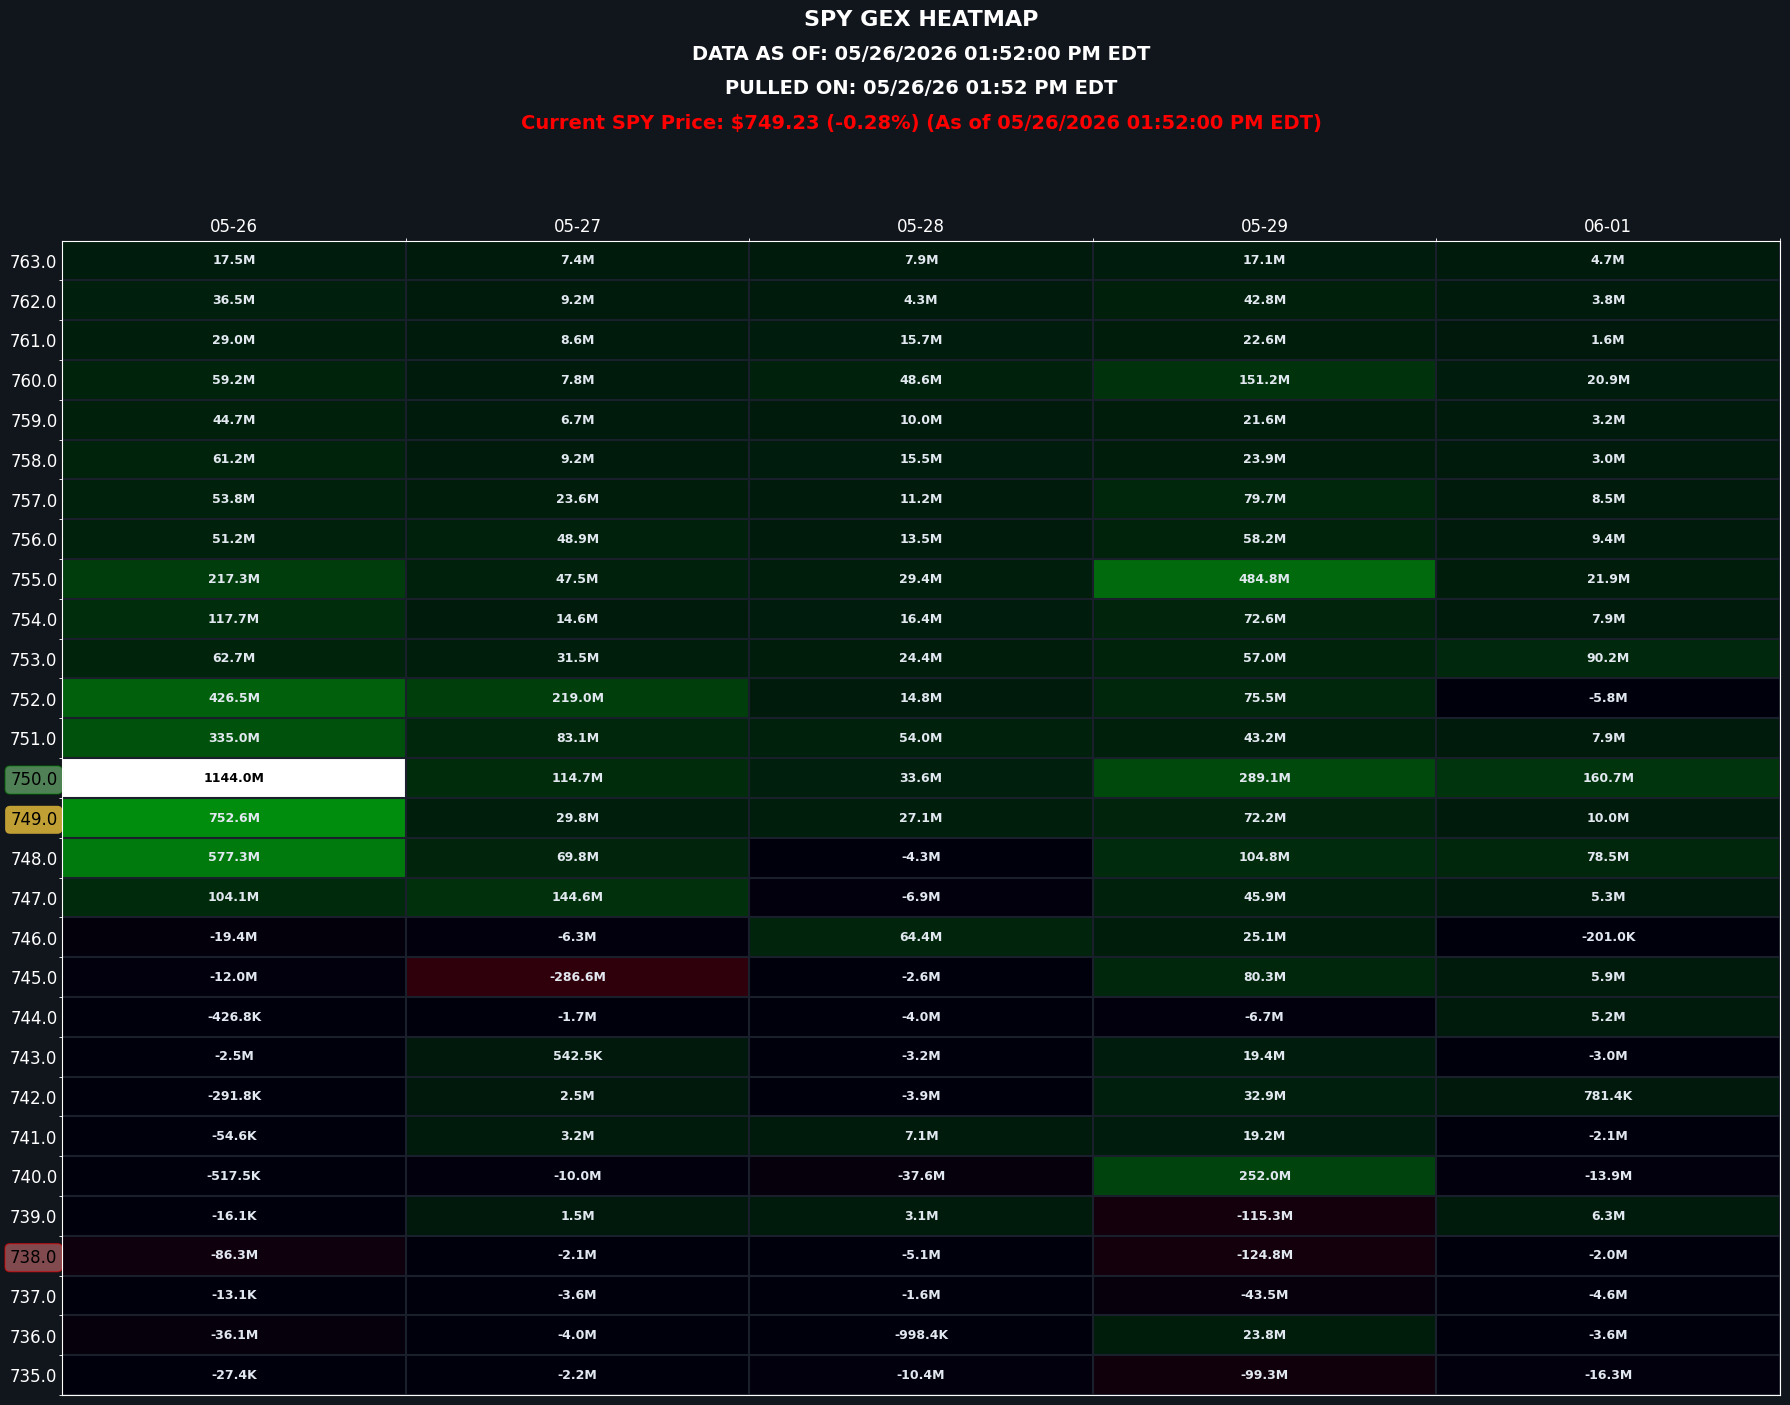

In [6]:
import datetime
import pytz # Import pytz for timezone handling

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(18, 14), facecolor='#11151c') # Increased figure size
ax.set_facecolor('#11151c')

# Draw the custom-colored grid tiles natively using imshow
ax.imshow(rgba_matrix, aspect='auto')

# Generate explicit crisp grid boundary cuts between individual boxes
ax.set_xticks(np.arange(df_heatmap.shape[1]) + 0.5, minor=True)
ax.set_yticks(np.arange(df_heatmap.shape[0]) + 0.5, minor=True)
ax.grid(which='minor', color='#1a1f2c', linestyle='-', linewidth=1.5);

# Set main tracking labels
ax.set_xticks(np.arange(df_heatmap.shape[1]))
ax.set_xticklabels([pd.to_datetime(d).strftime('%m-%d') for d in df_heatmap.columns]) # Format expiry dates for x-axis
ax.set_yticks(np.arange(df_heatmap.shape[0]))
ax.set_yticklabels(df_heatmap.index)

# Apply text annotations directly on top of coordinates
for r_idx in range(df_heatmap.shape[0]):
    for c_idx in range(df_heatmap.shape[1]):
        label_text = df_annotations.iloc[r_idx, c_idx]
        if label_text != "":
            # Contrast inversion rule: flip text to black if background cell is bright blue
            is_blue_block = (np.abs(df_heatmap.iloc[r_idx, c_idx]) == global_max_val)
            text_color = '#000000' if is_blue_block else '#e2e8f0'

            # If the cell is white (highest absolute GEX for current day), make text black for contrast
            if abs_max_gex_row_idx_for_cell_color != -1 and r_idx == abs_max_gex_row_idx_for_cell_color and c_idx == 0:
                text_color = '#000000'

            ax.text(c_idx, r_idx, label_text, ha='center', va='center',
                    color=text_color, fontsize=9, fontweight='bold')

# Structure terminal alignment
ax.xaxis.tick_top()
ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='white', length=0) # Increased labelsize and set labelcolor to white

# Use the timestamp of the last trade from yfinance for "Data As Of"
# last_trade_datetime_est is a Timestamp object, so format it directly.
# This variable is established in Cell 8ZMn7RiXShkq.
timestamp_data_as_of = last_trade_datetime_est.strftime('%m/%d/%Y %I:%M:%S %p %Z')

# Get current UTC time and convert to EST for "PULLED ON"
utc_now = datetime.datetime.now(pytz.utc)
est_timezone = pytz.timezone('America/New_York')
est_now = utc_now.astimezone(est_timezone)
pulled_on_timestamp = est_now.strftime('%m/%d/%y %I:%M %p %Z')

# Determine the date of the spot price (which is the date of the last trade)
spot_price_date = last_trade_datetime_est.date()

# Filter history_data to get all 1-minute data for the spot price's date
# This includes pre-market, regular market, and after-hours for that day
current_day_data = history_data[history_data.index.date == spot_price_date]

# Get the opening price for that specific trading day.
# We take the first 'Open' from this filtered data, which will be the day's true open
# (or earliest available data for that day including pre-market if present).
if not current_day_data.empty:
    daily_open_price = current_day_data['Open'].iloc[0]
else:
    # Fallback if no data found for the current day (should not happen if spot_price is defined)
    daily_open_price = spot_price # If no open data, assume no change for the day

daily_change_percent = ((spot_price - daily_open_price) / daily_open_price) * 100
change_color = 'green' if daily_change_percent >= 0 else 'red'
daily_change_str = f" ({daily_change_percent:+.2f}%)"

# --- Title construction with mixed colors using ax.text for each line ---

# Prepare title components
title_line_1 = "SPY GEX HEATMAP"
title_line_2 = f"DATA AS OF: {timestamp_data_as_of}"
title_line_3 = f"PULLED ON: {pulled_on_timestamp}"
last_line_content = f"Current SPY Price: ${spot_price:.2f}{daily_change_str} (As of {timestamp_data_as_of})"

# Position the title lines manually using ax.text
y_pos = 1.2 # Increased starting Y position to ensure text is well above the plot area
line_height_factor = 0.03 # Adjust for desired spacing between lines (increased for more space)

ax.text(0.5, y_pos, title_line_1,
        fontsize=16, fontweight='bold', color='white',
        ha='center', va='top', transform=ax.transAxes)

ax.text(0.5, y_pos - line_height_factor, title_line_2,
        fontsize=14, fontweight='bold', color='white',
        ha='center', va='top', transform=ax.transAxes)

ax.text(0.5, y_pos - 2 * line_height_factor, title_line_3,
        fontsize=14, fontweight='bold', color='white',
        ha='center', va='top', transform=ax.transAxes)

ax.text(0.5, y_pos - 3 * line_height_factor, last_line_content,
        fontsize=14, fontweight='bold', color=change_color,
        ha='center', va='top', transform=ax.transAxes)


# Identify the strikes with the highest positive and most negative GEX for the current day (first expiry)
current_day_gex = df_heatmap.iloc[:, 0] # Selects the first column for all rows

current_day_max_gex = current_day_gex.max()
current_day_min_gex = current_day_gex.min()

max_gex_strike = None
min_gex_strike = None

if current_day_max_gex > 0:
    max_gex_strike = current_day_gex.idxmax()

if current_day_min_gex < 0:
    min_gex_strike = current_day_gex.idxmin()

# Identify the strike with the maximum absolute GEX for the current day
abs_max_gex_strike = None
if not current_day_gex.empty:
    abs_max_gex_strike = current_day_gex.abs().idxmax()

# Add real-time visual highlight banner for the Y-Axis tick element nearest to current spot
spot_idx = np.argmin(np.abs(np.array(df_heatmap.index) - spot_price))
ylabels = ax.get_yticklabels()

# Initialize a set to keep track of already highlighted indices to prevent overwrites
highlighted_indices = set()

# Highlight the strike corresponding to the max positive GEX (Call Wall) for the current day (lightgreen)
if max_gex_strike is not None:
    max_gex_idx = df_heatmap.index.get_loc(max_gex_strike)
    if max_gex_idx not in highlighted_indices:
        ylabels[max_gex_idx].set_bbox(dict(facecolor='lightgreen', alpha=0.5, edgecolor='green', boxstyle='round,pad=0.3'))
        ylabels[max_gex_idx].set_color('black')
        highlighted_indices.add(max_gex_idx)

# Highlight the strike corresponding to the min negative GEX (Put Wall) for the current day (lightcoral)
if min_gex_strike is not None:
    min_gex_idx = df_heatmap.index.get_loc(min_gex_strike)
    if min_gex_idx not in highlighted_indices:
        ylabels[min_gex_idx].set_bbox(dict(facecolor='lightcoral', alpha=0.5, edgecolor='red', boxstyle='round,pad=0.3'))
        ylabels[min_gex_idx].set_color('black')
        highlighted_indices.add(min_gex_idx)

# Highlight the spot price (yellow)
if spot_idx not in highlighted_indices:
    ylabels[spot_idx].set_bbox(dict(facecolor='#d4af37', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.3'))
    ylabels[spot_idx].set_color('black')
    highlighted_indices.add(spot_idx)

plt.tight_layout()
plt.show()